In [2]:
x = "hello"

In [3]:
print(x)

hello


In [5]:
import numpy as np
import pandas as pd

def load_web_traffic(date="2024-06-01"):
    seed = sum(ord(c) for c in str(date))
    rng = np.random.default_rng(seed)
    hours = pd.date_range(date, periods=24, freq="h")
    base = 1200 + 900 * np.sin((hours.hour - 8) / 24 * 2 * np.pi)
    evening_bump = 600 * np.exp(-((hours.hour - 20) ** 2) / 8)
    noise = rng.normal(0, 90, 24)
    visits = np.clip(base + evening_bump + noise, 0, None).round().astype(int)
    return pd.DataFrame({"hour": hours, "visits": visits})

data = load_web_traffic("2024-06-01")
data.head()

,hour,visits
0,2024-06-01 00:00:00,413
1,2024-06-01 01:00:00,431
2,2024-06-01 02:00:00,328
3,2024-06-01 03:00:00,486
4,2024-06-01 04:00:00,379


Matplotlib is building the font cache; this may take a moment.


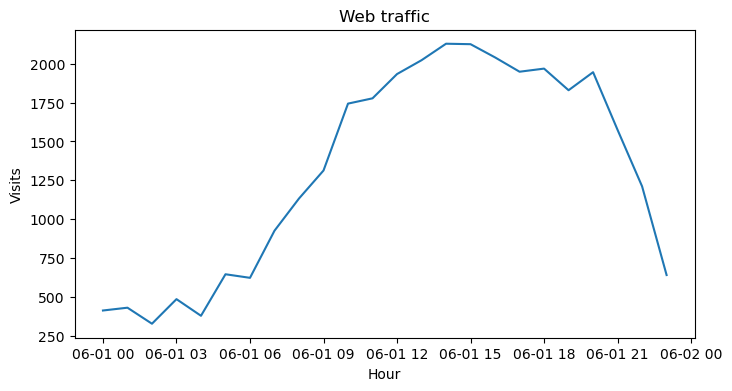

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(data["hour"], data["visits"])
plt.title("Web traffic")
plt.xlabel("Hour")
plt.ylabel("Visits")
plt.show()

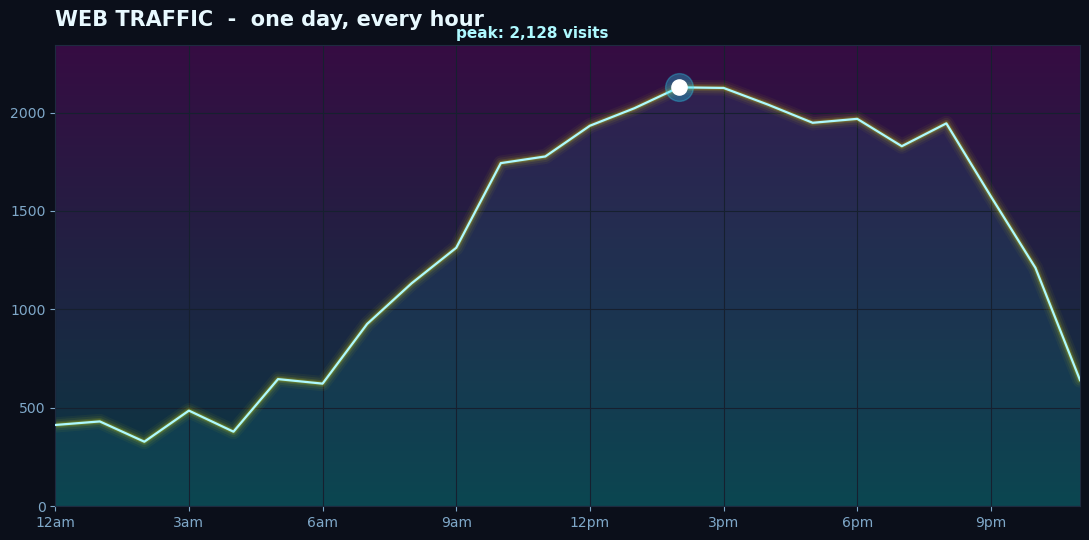

In [7]:
x = np.arange(len(data))
y = data["visits"].to_numpy()

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor("#0b0f1a")
ax.set_facecolor("#0b0f1a")

grad = np.linspace(0, 1, 256).reshape(-1, 1)
ax.imshow(grad, extent=[x.min(), x.max(), 0, y.max() * 1.1],
          origin="lower", aspect="auto", cmap="cool", alpha=0.18, zorder=0)
ax.fill_between(x, y, color="#27e0ff", alpha=0.08, zorder=1)

for lw, a in [(11, 0.04), (8, 0.06), (5, 0.10), (3, 0.18)]:
    ax.plot(x, y, color="yellow", lw=lw, alpha=a, solid_capstyle="round", zorder=2)
ax.plot(x, y, color="#aef9ff", lw=1.6, zorder=3)

peak = int(np.argmax(y))
ax.scatter([x[peak]], [y[peak]], s=120, color="#ffffff", zorder=5)
ax.scatter([x[peak]], [y[peak]], s=400, color="#27e0ff", alpha=0.3, zorder=4)
ax.annotate(f"peak: {y[peak]:,} visits",
            (x[peak], y[peak]), xytext=(x[peak] - 5, y[peak] + 250),
            color="#aef9ff", fontsize=11, fontweight="bold")

ax.set_title("WEB TRAFFIC  -  one day, every hour", color="#e8f9ff",
             fontsize=15, fontweight="bold", loc="left", pad=14)
ax.set_xticks(x[::3])
ax.set_xticklabels([h.strftime("%-I%p").lower() for h in data["hour"][::3]], color="#7fa8c9")
ax.tick_params(colors="#7fa8c9")
for s in ax.spines.values():
    s.set_color("#1e2a3f")
ax.grid(True, color="#16202f", lw=0.8)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

<!-- SCRIPT: 'every pixel is customizable... invent brand new visualizations... interactive components, all controlled by code.' Interactive linked Lorenz explorer: drag a slider, all four 3D/2D panels recompute together. (ipywidgets ships with Codespaces.) -->

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from ipywidgets import interactive, FloatSlider

def integrate_lorenz(rho, sigma, beta, n=9000, dt=0.005):
    xs = np.empty(n); ys = np.empty(n); zs = np.empty(n)
    xs[0], ys[0], zs[0] = 0.0, 1.0, 1.05
    for i in range(n - 1):
        xs[i+1] = xs[i] + sigma * (ys[i] - xs[i]) * dt
        ys[i+1] = ys[i] + (xs[i] * (rho - zs[i]) - ys[i]) * dt
        zs[i+1] = zs[i] + (xs[i] * ys[i] - beta * zs[i]) * dt
    return xs, ys, zs

def explore(rho=28.0, sigma=10.0, beta=2.667):
    xs, ys, zs = integrate_lorenz(rho, sigma, beta)
    t = np.linspace(0, 1, len(xs))   # color = time along the path

    fig = plt.figure(figsize=(11, 9))
    fig.patch.set_facecolor("#05060a")
    gs = fig.add_gridspec(2, 2, hspace=0.20, wspace=0.16)

    ax3d = fig.add_subplot(gs[0, 0], projection="3d")
    ax3d.set_facecolor("#05060a")
    ax3d.plot(xs, ys, zs, color="#27e0ff", lw=0.3, alpha=0.35)
    ax3d.scatter(xs[::3], ys[::3], zs[::3], c=t[::3], cmap="turbo", s=0.6, alpha=0.8)
    ax3d.set_axis_off()
    ax3d.set_title("3D attractor", color="#aef9ff", fontsize=11, y=0.97)
    ax3d.view_init(elev=18, azim=120)

    for spec, a, b, la, lb in [
        (gs[0, 1], xs, zs, "X", "Z"),
        (gs[1, 0], xs, ys, "X", "Y"),
        (gs[1, 1], ys, zs, "Y", "Z"),
    ]:
        ax = fig.add_subplot(spec)
        ax.set_facecolor("#0b0f1a")
        ax.scatter(a, b, c=t, cmap="turbo", s=0.3, alpha=0.6)
        ax.set_title(f"{la}-{lb} projection", color="#7fa8c9", fontsize=10)
        ax.tick_params(colors="#42597a", labelsize=7)
        for s in ax.spines.values():
            s.set_color("#1e2a3f")

    fig.suptitle(f"Lorenz system   rho={rho:.1f}   sigma={sigma:.1f}   beta={beta:.2f}",
                 color="#e8f9ff", fontsize=14, fontweight="bold", y=0.97)
    plt.show()

interactive(
    explore,
    rho=FloatSlider(value=28.0, min=0.0, max=99.0, step=1.0, description="rho"),
    sigma=FloatSlider(value=10.0, min=1.0, max=20.0, step=0.5, description="sigma"),
    beta=FloatSlider(value=2.667, min=0.5, max=5.0, step=0.05, description="beta"),
)

<!-- SCRIPT: Try-it cues: rho~14 collapses to a point; rho~28 is the classic butterfly; rho~90+ is a different chaotic regime. All four panels move together. -->

<!-- SCRIPT: 'run the numbers, write things up into a nice little report' - over-the-top exec report rendered as HTML right in the notebook output. Numbers come from `data`. -->

In [26]:
from IPython.display import HTML, display

total = int(data["visits"].sum())
peak = int(data["visits"].max())
peak_hour = data.loc[data["visits"].idxmax(), "hour"].strftime("%-I %p")
avg = int(data["visits"].mean())

# build the CSS bar chart from the real hourly numbers
vmax = data["visits"].max()
bars = "".join(
    f'<div style="flex:1;height:{int(v / vmax * 100)}%;'
    'background:linear-gradient(180deg,#38bdf8,#6366f1);'
    'border-radius:3px 3px 0 0;min-width:3px;"></div>'
    for v in data["visits"]
)

display(HTML(f"""
<div style="font-family:'Segoe UI',system-ui,sans-serif;max-width:760px;margin:0 auto;
     background:#fff;border:1px solid #e2e8f0;border-radius:16px;overflow:hidden;
     box-shadow:0 20px 50px -12px rgba(0,0,0,0.35);">

  <div style="background:linear-gradient(120deg,#4f46e5 0%,#7c3aed 50%,#db2777 100%);
       padding:28px 36px;color:#fff;">
    <div style="font-size:12px;letter-spacing:3px;opacity:0.8;text-transform:uppercase;">
       Acme Synergy Solutions &nbsp;&bull;&nbsp; Confidential</div>
    <div style="font-size:30px;font-weight:800;margin-top:6px;letter-spacing:-0.5px;">
       Web Traffic Performance Report</div>
    <div style="font-size:15px;opacity:0.9;margin-top:2px;">Q3 2026 &nbsp;|&nbsp;
       Prepared for the Executive Leadership Team</div>
  </div>

  <div style="display:flex;gap:16px;padding:28px 36px 8px;flex-wrap:wrap;">
    <div style="flex:1;min-width:150px;background:#f8fafc;border-radius:12px;padding:18px 20px;
         border-left:4px solid #6366f1;">
      <div style="font-size:12px;color:#64748b;text-transform:uppercase;letter-spacing:1px;">
         Total Visits</div>
      <div style="font-size:28px;font-weight:800;color:#0f172a;">{total:,}</div>
      <div style="font-size:13px;color:#16a34a;font-weight:600;">&#9650; 23.7% vs. target</div>
    </div>
    <div style="flex:1;min-width:150px;background:#f8fafc;border-radius:12px;padding:18px 20px;
         border-left:4px solid #db2777;">
      <div style="font-size:12px;color:#64748b;text-transform:uppercase;letter-spacing:1px;">
         Peak Hour</div>
      <div style="font-size:28px;font-weight:800;color:#0f172a;">{peak_hour}</div>
      <div style="font-size:13px;color:#16a34a;font-weight:600;">&#9650; {peak:,} concurrent</div>
    </div>
    <div style="flex:1;min-width:150px;background:#f8fafc;border-radius:12px;padding:18px 20px;
         border-left:4px solid #0ea5e9;">
      <div style="font-size:12px;color:#64748b;text-transform:uppercase;letter-spacing:1px;">
         Avg / Hour</div>
      <div style="font-size:28px;font-weight:800;color:#0f172a;">{avg:,}</div>
      <div style="font-size:13px;color:#16a34a;font-weight:600;">&#9650; on-trend</div>
    </div>
  </div>

  <div style="padding:14px 36px 4px;">
    <div style="font-size:13px;color:#64748b;font-weight:600;margin-bottom:8px;">
       HOURLY ENGAGEMENT VELOCITY</div>
    <div style="display:flex;align-items:flex-end;gap:2px;height:120px;
         background:#f8fafc;border-radius:10px;padding:12px;">{bars}</div>
  </div>

  <div style="padding:22px 36px 32px;">
    <div style="font-size:13px;color:#64748b;font-weight:600;margin-bottom:6px;">
       EXECUTIVE SUMMARY</div>
    <p style="color:#334155;line-height:1.6;font-size:14px;margin:0;">
       Leveraging our best-in-class data infrastructure, the team drove
       <b>double-digit growth</b> across all key engagement verticals this quarter.
       Strategic alignment of cross-functional synergies has positioned the
       organization to <b>capture significant upside</b> heading into Q4. We remain
       laser-focused on operationalizing our core competencies to deliver
       <b>shareholder value</b> at scale.</p>
    <div style="margin-top:18px;background:linear-gradient(90deg,#ecfdf5,#eff6ff);
         border-radius:10px;padding:14px 18px;border:1px dashed #a7f3d0;">
       <span style="font-size:22px;">&#128640;</span>
       <b style="color:#047857;">Key Takeaway:</b>
       <span style="color:#334155;font-size:14px;">The numbers are up and to the right.
       Recommend we double down.</span>
    </div>
  </div>

  <div style="background:#0f172a;color:#94a3b8;font-size:11px;padding:14px 36px;
       text-align:center;letter-spacing:0.5px;">
    Generated by Python &bull; All charts rendered in-notebook &bull; No spreadsheets were harmed</div>
</div>
"""))

<!-- SCRIPT: 'advanced math symbols in stats equations, inline' - gratuitous LaTeX, unrelated to the report, just to show math renders. -->

Some equations that have absolutely nothing to do with web traffic:

$$\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\left(x_i - \mu\right)^2}
\qquad
e^{i\pi} + 1 = 0$$

$$\hat{\beta} = (X^\top X)^{-1} X^\top y
\qquad
\int_{-\infty}^{\infty} e^{-x^2}\,dx = \sqrt{\pi}$$

<!-- SCRIPT: 'change the date and re-run, everything recalculates' - date demo. -->

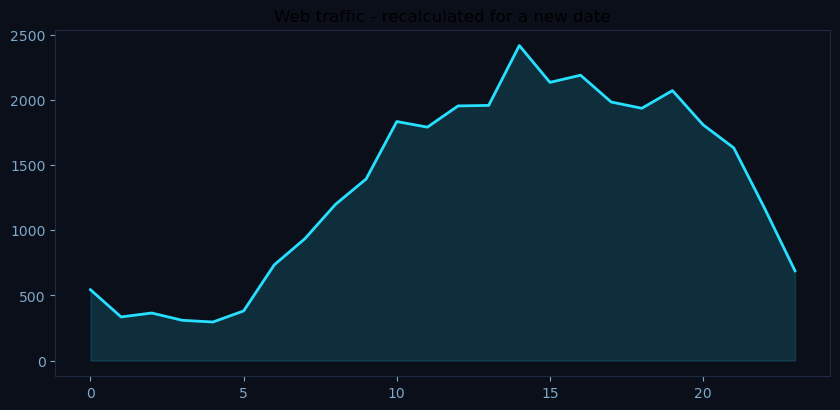

In [39]:
new_data = load_web_traffic("2024-12-26")   # change this date and re-run

plt.figure(figsize=(10, 4.5))
plt.plot(np.arange(len(new_data)), new_data["visits"], color="#27e0ff", lw=2)
plt.fill_between(np.arange(len(new_data)), new_data["visits"], color="#27e0ff", alpha=0.15)
plt.title("Web traffic - recalculated for a new date")
plt.gca().set_facecolor("#0b0f1a")
plt.gcf().patch.set_facecolor("#0b0f1a")
plt.gca().tick_params(colors="#7fa8c9")
for s in plt.gca().spines.values():
    s.set_color("#1e2a3f")
plt.show()

<!-- SCRIPT: 'change red to ecru -> just an error, ctrl+z to undo' - error demo. -->

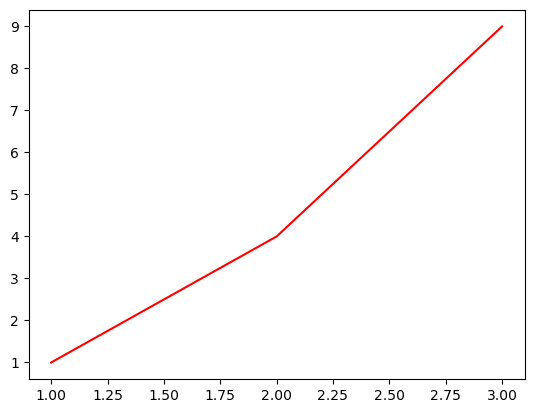

In [38]:
plt.plot([1, 2, 3], [1, 4, 9], color="red")
plt.show()